# 1. Scenario definition and problem framing discussion

This notebook is where the thesis moves from background into the concrete scheduling problem. The aim is not to sweep many deployments. It is to lock one 3GPP-aligned NR downlink scenario, fix the PA choices and the compliant resource envelope, and make the scheduler decision explicit: for a given user requirement, which combination of PA option, PRBs, layers, and MCS meets that requirement with the lowest active PA energy?

That fixed framing matters because the later notebooks do not introduce new radio assumptions. They inherit the same preset and work only on the allocation problem that remains inside it.

The PA power contract is slot-level: PRBs shape payload, occupied bandwidth, and feasibility, while PA DC power is evaluated from the active-slot RF output operating point.

## 1. Problem statement

Earlier chapters established why network energy matters, why the PA is a meaningful part of that budget, and why mixed-PA hardware is interesting in a compliant NR transmitter. The missing step is operational: once downlink demand arrives in one fixed deployment, what is the scheduler actually allowed to choose, and what exactly should it optimize?

This first notebook answers that by separating three things clearly:

- what stays fixed by the scenario and the 3GPP-aligned preset,
- what the scheduler is allowed to vary for each served user,
- what later notebooks will minimize when they compare feasible allocations.

In [8]:
import sys
from pathlib import Path
from IPython.display import display

repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent

for path in (repo_root / "notebooks", repo_root / "src"):
    resolved = str(path.resolve())
    if resolved not in sys.path:
        sys.path.insert(0, resolved)

from helpers.scenario_definition_helpers import ScenarioDefinitionHelpers

# Notebook-wide visual identity: change this once to rerun under the other institutional theme.
helper = ScenarioDefinitionHelpers(theme="aalto_elec")
helper.display_contract_flowchart()

artifacts = helper.build_artifacts(
    distance_m=200.0,
    required_rate_bps=120e6,
)


<IPython.core.display.Javascript object>

In [9]:
display(
    helper.render_table(
        artifacts.problem_statement,
        caption="Scheduler-level framing of what the study keeps fixed, what it allocates, and what it optimizes.",
    )
)

question,answer
What is fixed?,"The scenario, PA catalog, and compliant PHY search space are fixed by the shared radio preset."
What is allocated?,"Each active user is represented by one active-slot scheduler row built from PA choice, PRBs, layers, and MCS."
What is optimized?,The active-slot PA DC power is minimized while the operating row still carries the strongest feasible payload per slot.


## 1.1 From fixed scenario to scheduler contract

The role of this notebook is deliberately narrow. It does not solve multi-user scheduling yet. It fixes the deployment, waveform, and PA catalog, then reduces them to the lean scheduler-facing contract that later notebooks reuse for user generation, candidate evaluation, lookup, and TDMA assignment.

The next table is therefore a scenario table, not a result table. It locks the assumptions that every later step inherits so the rest of the notebook chain can focus on allocation choices instead of repeatedly reintroducing the deployment.

In [10]:
display(
    helper.render_table(
        artifacts.radio_assumptions,
        caption="Fixed deployment, propagation, waveform, and RF assumptions that anchor the rest of the notebook chain.",
    )
)

group,assumption,value
Deployment,Downlink channel,3GPP NR PDSCH shared downlink channel
Deployment,Scenario,3GPP NR micro cell in band n78
Deployment,Carrier frequency,3.5 GHz
Deployment,Channel bandwidth,100 MHz
Propagation,Path-loss model,umi_sc_nlos
Propagation,BS / UE heights,10.0 m / 1.5 m
Propagation,Antenna gains,"8.0 dB TX, 0.0 dB RX"
Link budget,Thermal noise density,-174 dBm/Hz
Link budget,LNA noise figure,5.0 dB
Link budget,Implementation loss,3.0 dB


## 2. Hardware options and compliant resource space

Once the deployment is fixed, the remaining question is what choice set the scheduler actually sees. The study keeps one fixed n78 100 MHz carrier on one 4-MIMO sub-array with four transmit chains. Within that envelope, the scheduler does not redesign the waveform; it only chooses among compliant PA options and admissible PHY allocations.

The next table lists the measured PA families available on each chain. The following table then reduces the NR preset to the scheduler-facing dimensions that survive into the stored candidate contract. The empty-frame visual makes that resource envelope tangible before any user is placed into it.

In [11]:
display(
    helper.render_table(
        artifacts.pa_characteristics[
            ["pa_id", "scenario_label", "pa_name", "p_max_w", "p_idle_w", "eta_max"]
        ],
        formats={
            "p_max_w": "{:.1f}",
            "p_idle_w": "{:.2f}",
            "eta_max": "{:.2f}",
        },
        caption="Measured PA options available per transmit chain under the fixed study scenario.",
    )
)

pa_id,scenario_label,pa_name,p_max_w,p_idle_w,eta_max
0,8W PA,Bae et al. NR,7.9,3.84,0.42
1,4W PA,QPA9942,1.8,0.42,0.35


In [12]:
display(
    helper.render_table(
        artifacts.phy_resource_space,
        caption="Fixed scheduler-facing NR resource envelope inherited by the later notebooks.",
    )
)


dimension,admitted_values,note
numerology,"mu = 1, Delta f = 30 kHz",The study keeps one fixed NR numerology for the micro-cell PDSCH downlink.
frame_n_slots,20 slots per 10.0 ms frame,Later notebooks allocate within this fixed empty downlink frame.
channel_bw_hz,100 MHz,The candidate table is built for one fixed carrier bandwidth.
n_prb,1 to 277 PRBs in steps of 5,Frequency allocation varies only through the PRB count inside the fixed carrier.
layers,"1, 2, 3, 4",The active layer count is bounded by the 4-chain sub-array.
mcs,0 to 28,The NR MCS reference table fixes the admissible coding points.
Stored table columns,"pa_id, n_prb, layers, mcs, bits_per_slot, p_dc_active_w, p_out_total_w",This lean slot-normalized contract is reused by user lookup before TDMA slot quantization.


The figure below is deliberately empty. It shows the geometry of the available downlink frame before any PRBs, layers, or slots are committed to a user. Reading it this way helps separate the fixed NR envelope from the user allocations that later notebooks optimize.

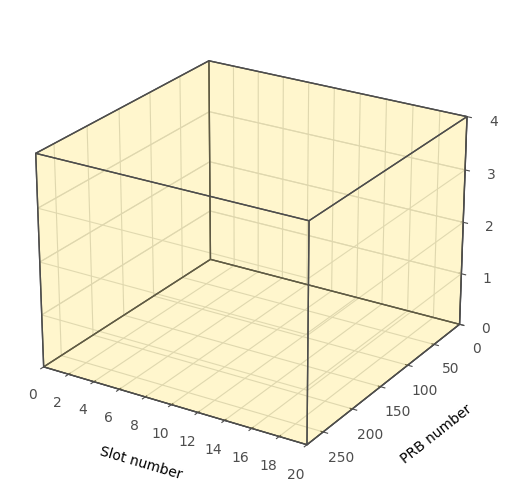

In [13]:
fig = helper.plot_empty_pdsch_frame(artifacts.scenario)


Empty NR PDSCH frame envelope for the fixed micro-cell preset. Read it as the scheduler's available three-dimensional allocation space: `20` slots across time, `277` PRBs across frequency, and up to `4` ranks across layers within one `10 ms` frame at `30 kHz` subcarrier spacing on the fixed `100 MHz` carrier.

## 3. PA behavior and the bridge to candidate generation

Fixing the resource space is only half of the problem. The allocation question is non-trivial because PA energy does not scale uniformly across operating points. Changing occupied bandwidth, layer count, or required output power can also change which PA option is most attractive.

The PA curves therefore explain why the later notebooks need explicit candidate evaluation instead of a simple rule of thumb. This notebook still stops before stored rows are generated: it only defines the physical behavior and decision space that candidate generation will use.

(<Figure size 600x900 with 2 Axes>,
 (<Axes: xlabel='Average PA output power (dBm)', ylabel='Gain (dB)'>,
  <Axes: ylabel='PAE (%)'>))

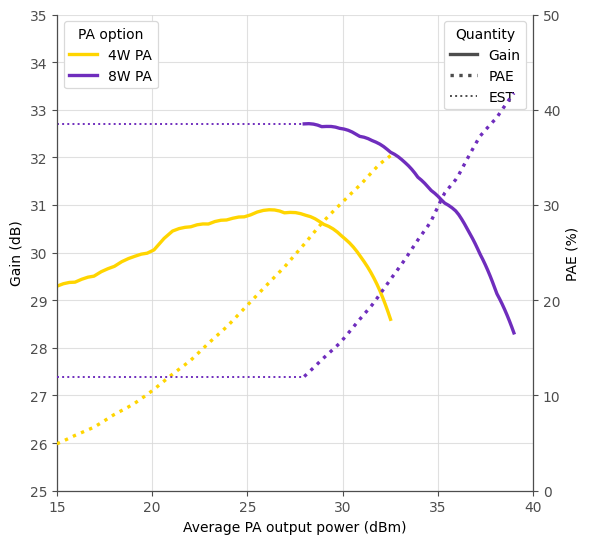

In [14]:
helper.plot_pa_gain_and_pae(artifacts.pa_curve_table)


This notebook has done its job once two things are fixed: the study scenario and the scheduler's admissible choice set. The next notebook makes user demand concrete by generating the user conditions that query this shared resource space. After that, the candidate-evaluation and candidate-space notebooks turn those feasible operating points into the stored rows used later in scheduling.